<a href="https://colab.research.google.com/github/Sampritisahoo/DEEP_LEARNING/blob/main/XAI_GRAND_CAMP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#image identifer

In [ ]:
# ============================================================
# XAI FOR CNNs USING GRAD-CAM (SINGLE GOOGLE COLAB CELL)
# ============================================================

# Install Grad-CAM library
!pip install grad-cam -q

# Import PyTorch framework
import torch

# Import torchvision for pretrained CNN models
import torchvision

# Import ResNet weights class (new torchvision syntax)
from torchvision.models import resnet18, ResNet18_Weights
# Import image transforms
import torchvision.transforms as transforms

# Import matplotlib for displaying images
import matplotlib.pyplot as plt

# Import numpy for numerical operations
import numpy as np

# PIL library for image handling
from PIL import Image

# requests library for downloading images
import requests
# BytesIO converts downloaded bytes to image
from io import BytesIO

# Import Grad-CAM explanation tool
from pytorch_grad_cam import GradCAM

# Utility to overlay heatmap on image
from pytorch_grad_cam.utils.image import show_cam_on_image

# Used to specify class target
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
# STEP 1: LOAD PRETRAINED CNN MODEL
# ------------------------------------------------------------

# Load ResNet18 with ImageNet pretrained weights
weights = ResNet18_Weights.DEFAULT

# Initialize model
model = resnet18(weights=weights)

# Set model to evaluation mode
model.eval()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.6MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# ------------------------------------------------------------
# STEP 2: SELECT TARGET LAYER FOR GRAD-CAM
# ------------------------------------------------------------

# Choose the last convolution layer
target_layers = [model.layer4[-1]]

In [ ]:
# ------------------------------------------------------------
# STEP 3: DOWNLOAD SAMPLE IMAGE
# ------------------------------------------------------------

# Image URL (dog image)
url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"

# Add user-agent to avoid 403 error
headers = {"User-Agent": "Mozilla/5.0"}

# Send request
response = requests.get(url, headers=headers)

# Check if download successful
if response.status_code != 200:
    raise ValueError("Image download failed")

# Convert downloaded bytes to image
img = Image.open(BytesIO(response.content)).convert("RGB")


In [ ]:
# ------------------------------------------------------------
# STEP 4: PREPROCESS IMAGE
# ------------------------------------------------------------

# Use preprocessing from pretrained weights
preprocess = weights.transforms()

# Apply preprocessing
input_tensor = preprocess(img)

# Add batch dimension
input_tensor = input_tensor.unsqueeze(0)

In [ ]:
# ------------------------------------------------------------
# STEP 5: CNN PREDICTION
# ------------------------------------------------------------

# Run forward pass
output = model(input_tensor)

# Get predicted class index
predicted_class = output.argmax().item()

# Print predicted class
print("Predicted Class Index:", predicted_class)

Predicted Class Index: 207


In [ ]:
# ------------------------------------------------------------
# STEP 6: APPLY GRAD-CAM
# ------------------------------------------------------------

# Initialize Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

# Specify target class
targets = [ClassifierOutputTarget(predicted_class)]

# Generate Grad-CAM heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

# Remove batch dimension
grayscale_cam = grayscale_cam[0]

In [ ]:
# ------------------------------------------------------------
# STEP 7: PREPARE IMAGE FOR VISUALIZATION
# ------------------------------------------------------------

# Resize original image to CNN input size
img_resized = img.resize((224,224))

# Convert to numpy
img_np = np.array(img_resized) / 255.0


# Overlay heatmap on original image
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

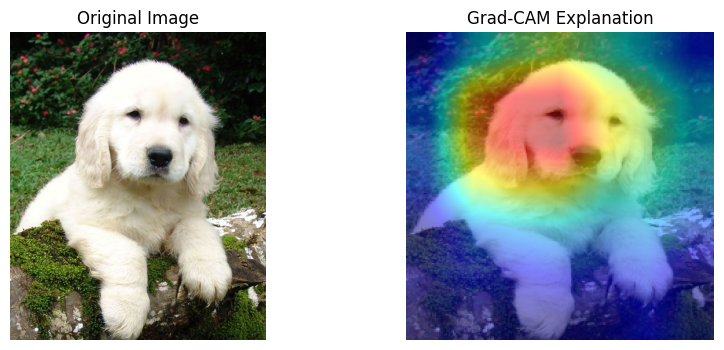

In [ ]:
# ------------------------------------------------------------
# STEP 8: DISPLAY RESULTS
# ------------------------------------------------------------

plt.figure(figsize=(10,4))

# Show original image
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Show Grad-CAM explanation
plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM Explanation")
plt.axis("off")

plt.show()

In [ ]:
# ------------------------------------------------------------
# STEP 9: INTERPRETATION
# ------------------------------------------------------------

print("\nExplanation:")
print("Highlighted regions show which parts of the image influenced the CNN prediction.")
print("This demonstrates Explainable AI (XAI) using Grad-CAM.")


Explanation:
Highlighted regions show which parts of the image influenced the CNN prediction.
This demonstrates Explainable AI (XAI) using Grad-CAM.
